In [1]:
import pandas as pd
import numpy as np

from pathlib import Path

# Go up two directories, then into 02_processed_data
csv_path = Path.cwd().parents[1] / "02_processed_data" / "final_df_insurance_merged_data_in_california.csv"

df = pd.read_csv(csv_path, low_memory=False)

print("Loaded:", csv_path)
print("Shape:", df.shape)
df.head()

id_year = ["county_fips5", "yr"]
zip_year = ["ZIP Code", "yr"]

print("Shape:", df.shape)
print("Unique counties:", df["county_fips5"].nunique())
print("Year range:", df["yr"].min(), "to", df["yr"].max())

# ----------------------------
# 1) Key uniqueness checks
# ----------------------------
print("\n--- Uniqueness checks ---")
print("Duplicate (county,yr) rows:", df.duplicated(subset=id_year).sum())
print("Duplicate (ZIP,yr) rows   :", df.duplicated(subset=zip_year).sum())

if df.duplicated(subset=id_year).any():
    print("\nTop duplicated (county,yr) keys:")
    print(df.loc[df.duplicated(subset=id_year, keep=False), id_year]
            .value_counts().head(15))

if df.duplicated(subset=zip_year).any():
    print("\nTop duplicated (ZIP,yr) keys:")
    print(df.loc[df.duplicated(subset=zip_year, keep=False), zip_year]
            .value_counts().head(15))

# ----------------------------
# 2) Check if ZIP maps to multiple counties (classic merge issue)
# ----------------------------
print("\n--- ZIP -> county mapping sanity ---")
zip_to_counties = df.groupby("ZIP Code")["county_fips5"].nunique().sort_values(ascending=False)
print("ZIPs mapping to >1 county:", int((zip_to_counties > 1).sum()))
if (zip_to_counties > 1).any():
    print("Examples of ZIPs with multiple counties:")
    bad_zips = zip_to_counties[zip_to_counties > 1].head(15).index.tolist()
    print(df[df["ZIP Code"].isin(bad_zips)][["ZIP Code","county_fips5","state","yr"]]
          .drop_duplicates().sort_values(["ZIP Code","yr"]).head(50))

# ----------------------------
# 3) Check if county has multiple ZIPs (normal) but verify aggregation is right
# ----------------------------
county_zip_counts = df.groupby(id_year)["ZIP Code"].nunique()
print("\nMedian #ZIPs per (county,yr):", float(county_zip_counts.median()))
print("Max #ZIPs per (county,yr):", int(county_zip_counts.max()))

# ----------------------------
# 4) Premium consistency: prem_per_unit should equal Earned Prem / Earned Exp
# ----------------------------
print("\n--- prem_per_unit consistency ---")
df["Earned Prem"] = pd.to_numeric(df["Earned Prem"], errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df["Earned Exp"],  errors="coerce")
df["prem_per_unit"] = pd.to_numeric(df["prem_per_unit"], errors="coerce")

eps = 1e-9
calc = df["Earned Prem"] / (df["Earned Exp"] + eps)

mask_valid = df["Earned Prem"].notna() & df["Earned Exp"].notna() & (df["Earned Exp"] > 0) & df["prem_per_unit"].notna()
diff = (df.loc[mask_valid, "prem_per_unit"] - calc.loc[mask_valid]).abs()

print("Rows with Earned Exp > 0 and prem_per_unit present:", int(mask_valid.sum()))
print("Median abs diff:", float(diff.median()) if len(diff) else None)
print("95th pct abs diff:", float(np.percentile(diff, 95)) if len(diff) else None)

# show worst mismatches
if len(diff) > 0:
    worst_idx = diff.sort_values(ascending=False).head(20).index
    print("\nWorst prem_per_unit mismatches (top 20):")
    print(df.loc[worst_idx, ["yr","ZIP Code","county_fips5","state","Earned Prem","Earned Exp","prem_per_unit"]]
          .assign(calc_prem_per_unit=calc.loc[worst_idx],
                  abs_diff=diff.loc[worst_idx])
          .sort_values("abs_diff", ascending=False))

# ----------------------------
# 5) Check for implausible values / placeholders
# ----------------------------
print("\n--- Value sanity ---")
print("Earned Exp <= 0:", int((df["Earned Exp"] <= 0).sum()))
print("Earned Prem < 0 :", int((df["Earned Prem"] < 0).sum()))
print("prem_per_unit <= 0:", int((df["prem_per_unit"] <= 0).sum()))

# distribution quick look
for c in ["Earned Prem","Earned Exp","prem_per_unit","hpi_change","hpi","unemployment_rate","real_gdp","prop_rate"]:
    if c in df.columns:
        s = pd.to_numeric(df[c], errors="coerce")
        print(f"\n{c} describe:")
        print(s.describe())

# ----------------------------
# 6) County FIPS consistency (if county_fips exists too)
# ----------------------------
print("\n--- county_fips vs county_fips5 ---")
if "county_fips" in df.columns:
    a = df["county_fips5"].astype("Int64").astype(str)
    b = pd.to_numeric(df["county_fips"], errors="coerce").astype("Int64").astype(str)
    mismatch = (a != b) & b.notna()
    print("Mismatches:", int(mismatch.sum()))
    if mismatch.any():
        print(df.loc[mismatch, ["yr","ZIP Code","county_fips5","county_fips","state"]].head(30))


Loaded: /Users/Jeep/Documents/duke_mss/stat_698/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data/final_df_insurance_merged_data_in_california.csv
Shape: (5692, 26)
Shape: (5692, 26)
Unique counties: 58
Year range: 2018 to 2020

--- Uniqueness checks ---
Duplicate (county,yr) rows: 5515
Duplicate (ZIP,yr) rows   : 0

Top duplicated (county,yr) keys:
county_fips5  yr  
6037.0        2018    286
              2019    285
              2020    284
6073.0        2020    112
              2019    112
              2018    108
6059.0        2018    100
              2019     98
6071.0        2018     98
6059.0        2020     98
6071.0        2019     97
              2020     96
6065.0        2020     81
              2018     78
              2019     76
Name: count, dtype: int64

--- ZIP -> county mapping sanity ---
ZIPs mapping to >1 county: 0

Median #ZIPs per (county,yr): 20.0
Max #ZIPs per (county,yr): 286

--- prem_per_unit consistency ---
Rows with E

In [2]:
df.dtypes

yr                             int64
ZIP Code                       int64
Earned Prem                    int64
Earned Exp                     int64
county_fips5                 float64
hpi_change                   float64
hpi                          float64
state                         object
flood_frequency              float64
flood_property_damage        float64
flood_duration_hours         float64
heat_stress_index            float64
drought_annual_mean_index    float64
fire_frequency               float64
fire_size                    float64
deaths_hurricane             float64
injuries_hurricane           float64
damage_hurricane             float64
real_gdp                     float64
unemployment_rate            float64
prop_rate                    float64
county_fips                  float64
total_home_purchase          float64
total_amt_purchase           float64
total_population             float64
prem_per_unit                float64
dtype: object

After cleaning: (5549, 28)
prem_per_unit 1%/99%: 571.7662565339767 5190.254651625734
MLR sample size: (5549, 28)
                            OLS Regression Results                            
Dep. Variable:             log_prem_w   R-squared:                       0.164
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     27.71
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           2.47e-20
Time:                        10:44:30   Log-Likelihood:                -2341.5
No. Observations:                5549   AIC:                             4713.
Df Residuals:                    5534   BIC:                             4812.
Df Model:                          14                                         
Covariance Type:              cluster                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 15, but rank is 14
  warnings.warn('covariance of constraints does not have full '


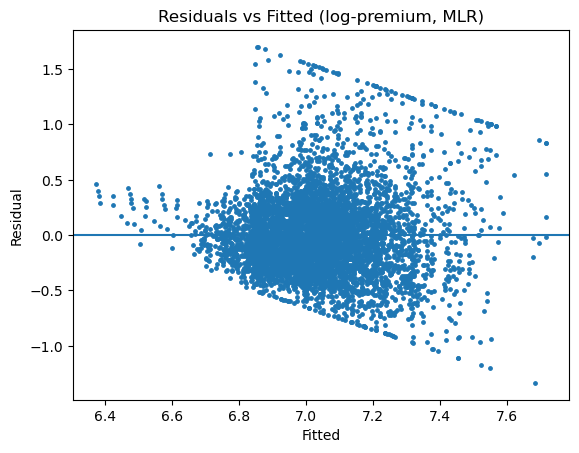

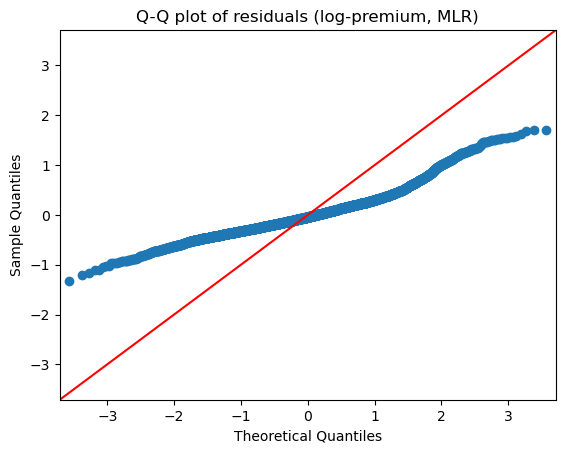


Top 15 coefficients by absolute magnitude (careful: includes dummies):
const                       -220.478280
heat_stress_index             -0.463444
prop_rate                     -0.261884
total_population              -0.146037
yr                             0.113040
real_gdp                       0.107656
Earned Exp                    -0.030721
unemployment_rate             -0.015386
hpi_change                    -0.007487
drought_annual_mean_index     -0.006372
flood_property_damage          0.005246
fire_size                     -0.003541
flood_frequency               -0.001026
fire_frequency                 0.000259
hpi                            0.000127
dtype: float64

Interpretation: +1 unit in hpi_change -> ~-0.75% change in prem_per_unit (holding others fixed).


NameError: name 'data_dir' is not defined

In [3]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path


# 2) Basic cleaning + types
# -----------------------------
num_cols = [
    "prem_per_unit","Earned Prem","Earned Exp","hpi_change","hpi",
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index","fire_frequency","fire_size",
    "deaths_hurricane","injuries_hurricane","damage_hurricane",
    "real_gdp","unemployment_rate","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population"
]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["state"] = df["state"].astype(str)

# keep valid target
df = df.dropna(subset=["prem_per_unit","yr","county_fips5","state"]).copy()
df = df[df["prem_per_unit"] > 0].copy()

# optional: winsorize heavy tail then log-transform target
lo, hi = df["prem_per_unit"].quantile([0.01, 0.99])
df["prem_w"] = df["prem_per_unit"].clip(lo, hi)
df["log_prem_w"] = np.log(df["prem_w"])

print("After cleaning:", df.shape)
print("prem_per_unit 1%/99%:", float(lo), float(hi))

# -----------------------------
# 3) Choose predictors for MLR
#    (Keep it moderate + interpretable)
# -----------------------------
base_predictors = [
    # exposure volume proxy (pricing often varies with risk/portfolio; also stabilizes)
    "Earned Exp",

    # housing market
    "hpi_change", "hpi",

    # macro
    "unemployment_rate", "real_gdp",

    # climate risk
    "flood_frequency", "flood_property_damage",
    "fire_frequency", "fire_size",
    "heat_stress_index", "drought_annual_mean_index",
    "damage_hurricane",

    # controls
    "total_population", "prop_rate"
]

# keep only columns that exist
base_predictors = [c for c in base_predictors if c in df.columns]

# drop rows missing predictors
df_m = df.dropna(subset=base_predictors + ["log_prem_w"]).copy()
print("MLR sample size:", df_m.shape)

# -----------------------------
# 4) Build design matrix with fixed effects (state + year)
# -----------------------------
X_num = df_m[base_predictors].copy()

# log-scale some skewed predictors (optional but often helps)
for c in ["Earned Exp", "real_gdp", "total_population", "flood_property_damage", "damage_hurricane", "fire_size"]:
    if c in X_num.columns:
        X_num[c] = np.log1p(X_num[c])

# add categorical fixed effects
X_cat = pd.get_dummies(df_m[["state", "yr"]].astype({"yr": "int"}), drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem_w"]

# -----------------------------
# 5) Fit MLR with clustered SE (county clusters)
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)
print(model.summary())

# -----------------------------
# 6) Basic diagnostics (residuals)
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

plt.figure()
plt.scatter(fitted, resid, s=6)
plt.axhline(0)
plt.title("Residuals vs Fitted (log-premium, MLR)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (log-premium, MLR)")
plt.show()

# -----------------------------
# 7) Interpret coefficients (approx % effect)
# -----------------------------
# For log(y): a 1-unit increase in X multiplies y by exp(beta)
# For small beta, it's ~100*beta % change.
coef = model.params.sort_values(key=lambda s: np.abs(s), ascending=False)
print("\nTop 15 coefficients by absolute magnitude (careful: includes dummies):")
print(coef.head(15))

# Example: effect of hpi_change in percent terms (approx)
if "hpi_change" in model.params.index:
    beta = model.params["hpi_change"]
    print(f"\nInterpretation: +1 unit in hpi_change -> ~{100*beta:.2f}% change in prem_per_unit (holding others fixed).")

# -----------------------------
# 8) (Optional) Save fitted values back
# -----------------------------
df_m["pred_log_prem_w"] = fitted
df_m["pred_prem_w"] = np.exp(df_m["pred_log_prem_w"])
out_path = data_dir / "mlr_predictions_logprem.csv"
df_m[[ "yr","ZIP Code","county_fips5","state","prem_per_unit","prem_w","pred_prem_w" ]].to_csv(out_path, index=False)
print("\nSaved:", out_path.resolve())


In [ ]:
cols = ["deaths_hurricane","injuries_hurricane","damage_hurricane"]
tmp = df_m[cols].copy()

print("Non-missing counts:\n", tmp.notna().sum())
print("\nUnique values (up to 10):")
for c in cols:
    print(c, tmp[c].dropna().unique()[:10])

print("\nFraction exactly zero:")
for c in cols:
    s = tmp[c].dropna()
    print(c, float((s == 0).mean()) if len(s) else None)

print("\nStd dev (0 => constant):")
print(tmp.std(numeric_only=True))

print("\nNon-zero row counts:")
for c in cols:
    s = tmp[c].dropna()
    print(c, int((s != 0).sum()))


In [ ]:
df

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from pathlib import Path


# 2) Types + cleaning
# -----------------------------
y_col = "prem_per_unit"
df[y_col] = pd.to_numeric(df[y_col], errors="coerce")
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["state"] = df["state"].astype(str)

# keep valid target
df = df.dropna(subset=[y_col, "yr", "county_fips5", "state"]).copy()
df = df[df[y_col] > 0].copy()

# winsorize + log target (helps a LOT)
lo, hi = df[y_col].quantile([0.01, 0.99])
df["prem_w"] = df[y_col].clip(lo, hi)
df["log_prem_w"] = np.log(df["prem_w"])

print("After cleaning:", df.shape)
print("prem_per_unit 1%/99%:", float(lo), float(hi))

# -----------------------------
# 3) Climate-only predictors
# -----------------------------
climate_vars = [
    "flood_frequency", "flood_property_damage", "flood_duration_hours",
    "heat_stress_index", "drought_annual_mean_index",
    "fire_frequency", "fire_size",
    "deaths_hurricane", "injuries_hurricane", "damage_hurricane"
]
climate_vars = [c for c in climate_vars if c in df.columns]

# numeric coercion
for c in climate_vars:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# drop rows missing any climate vars
df_m = df.dropna(subset=climate_vars + ["log_prem_w"]).copy()
print("Climate-only MLR sample size:", df_m.shape)
print("Climate vars used:", climate_vars)

# -----------------------------
# 4) Build X: climate vars + state/year FE
# -----------------------------
X_num = df_m[climate_vars].copy()

# log1p transform highly skewed damage/size variables (helps linearity)
for c in ["flood_property_damage", "damage_hurricane", "fire_size", "injuries_hurricane", "deaths_hurricane"]:
    if c in X_num.columns:
        X_num[c] = np.log1p(X_num[c])

X_cat = pd.get_dummies(df_m[["state", "yr"]].astype({"yr": "int"}), drop_first=True)

X = pd.concat([X_num, X_cat], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem_w"]

# -----------------------------
# 5) Fit with clustered SE (county)
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)
print(model.summary())

# -----------------------------
# 6) Quick diagnostics
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

plt.figure()
plt.scatter(fitted, resid, s=6)
plt.axhline(0)
plt.title("Residuals vs Fitted (climate-only MLR, log-premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

sm.qqplot(resid, line="45")
plt.title("Q-Q plot (climate-only MLR, log-premium)")
plt.show()

# -----------------------------
# 7) Interpret climate effects (approx % change)
# -----------------------------
# for log(y): 100*beta ≈ % change for +1 unit X (when beta small)
clim_coefs = model.params[[c for c in model.params.index if c in X_num.columns]]
clim_pvals = model.pvalues[[c for c in model.pvalues.index if c in X_num.columns]]

summary_tbl = pd.DataFrame({
    "beta": clim_coefs,
    "p_value": clim_pvals,
    "approx_%_per_1_unit": 100 * clim_coefs
}).sort_values("p_value")

print("\nClimate coefficients (sorted by p-value):")
print(summary_tbl)

# -----------------------------
# 8) Save fitted values
# -----------------------------
df_m["pred_log_prem_w"] = fitted
df_m["pred_prem_w"] = np.exp(df_m["pred_log_prem_w"])

out_path = data_dir / "mlr_climate_only_predictions.csv"
df_m[["yr","ZIP Code","county_fips5","state","prem_per_unit","prem_w","pred_prem_w"]].to_csv(out_path, index=False)
print("\nSaved:", out_path.resolve())


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

import shap

# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")
print("Dropped hurricane cols:", [c for c in hurr_cols if c in df.columns or c in hurr_cols])

# -----------------------------
# 3) Target: prem_per_unit (winsorize + log)
# -----------------------------
y_raw = "prem_per_unit"
df[y_raw] = pd.to_numeric(df[y_raw], errors="coerce")
df = df.dropna(subset=[y_raw]).copy()
df = df[df[y_raw] > 0].copy()

lo, hi = df[y_raw].quantile([0.01, 0.99])
df["prem_w"] = df[y_raw].clip(lo, hi)
df["y_model"] = np.log(df["prem_w"])

print("Target winsor 1%/99%:", float(lo), float(hi))
print("y_model = log(prem_w)")

# -----------------------------
# 4) Feature set: "all variables except hurricane + leakage + identifiers"
# -----------------------------
# Columns you should NOT use as features
drop_features = {
    y_raw, "prem_w", "y_model",
    "Earned Prem",          # leakage into prem_per_unit
    "Unnamed: 0"            # if present
}

# Optional: You may also want to drop ZIP if it's just an ID (high-cardinality).
# We'll keep it OUT by default for interpretability.
high_cardinality_ids = {"ZIP Code"}

# Strongly consider keeping county_fips5 as categorical? Often too many levels -> noisy.
# We'll keep it OUT by default.
other_ids = {"county_fips5", "county_fips"}

drop_features |= high_cardinality_ids | other_ids

feature_cols = [c for c in df.columns if c not in drop_features]
print("Num candidate feature cols:", len(feature_cols))

# Identify categorical vs numeric
# We'll treat "state" as categorical; everything else we'll coerce numeric if possible.
cat_cols = []
if "state" in feature_cols:
    cat_cols.append("state")

# Also treat any remaining object columns as categorical (low-ish cardinality)
obj_cols = [c for c in feature_cols if df[c].dtype == "object" and c != "state"]
cat_cols += obj_cols

num_cols = [c for c in feature_cols if c not in cat_cols]

# Coerce numeric columns
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

print("Numeric cols:", len(num_cols), "| Categorical cols:", len(cat_cols))
print("Categoricals:", cat_cols)

# Keep only needed columns
keep = feature_cols + ["y_model", y_raw, "prem_w"]
df_m = df[keep].copy()

# -----------------------------
# 5) Time-aware split: test=2020, train/val from others
# -----------------------------
if "yr" not in df_m.columns:
    raise ValueError("Expected 'yr' column for time-aware split.")

df_m["yr"] = pd.to_numeric(df_m["yr"], errors="coerce")
df_m = df_m.dropna(subset=["yr"]).copy()

test_year = 2020
test_df = df_m[df_m["yr"] == test_year].copy()
train_all = df_m[df_m["yr"] != test_year].copy()

train_df, val_df = train_test_split(train_all, test_size=0.2, random_state=42)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test(2020):", test_df.shape)

# -----------------------------
# 6) Preprocess
# -----------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop"
)

# -----------------------------
# 7) Model
# -----------------------------
rf = RandomForestRegressor(
    n_estimators=800,
    random_state=42,
    n_jobs=-1,
    max_depth=None,
    min_samples_leaf=5,
    max_features="sqrt"
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

# Fit
model.fit(train_df[feature_cols], train_df["y_model"].values)

# -----------------------------
# 8) Evaluation
# -----------------------------
def eval_split(name, d):
    X = d[feature_cols]
    y_true_log = d["y_model"].values
    y_pred_log = model.predict(X)

    mse = mean_squared_error(y_true_log, y_pred_log)
    rmse = float(np.sqrt(mse))
    mae = float(mean_absolute_error(y_true_log, y_pred_log))
    r2 = float(r2_score(y_true_log, y_pred_log))

    print(f"\n=== {name} (log scale) ===")
    print("N:", len(d))
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    prem_pred = np.exp(y_pred_log)
    prem_true = np.exp(y_true_log)

    mse_p = mean_squared_error(prem_true, prem_pred)
    rmse_p = float(np.sqrt(mse_p))
    mae_p = float(mean_absolute_error(prem_true, prem_pred))
    r2_p = float(r2_score(prem_true, prem_pred))

    print(f"=== {name} (premium scale) ===")
    print("RMSE:", rmse_p)
    print("MAE :", mae_p)
    print("R2  :", r2_p)

    return y_pred_log

_ = eval_split("TRAIN", train_df)
_ = eval_split("VAL", val_df)
y_pred_test_log = eval_split("TEST (2020)", test_df)

# -----------------------------
# 9) SHAP (TreeExplainer) on test sample
# -----------------------------
pre = model.named_steps["preprocess"]
rf_fitted = model.named_steps["rf"]

X_test = test_df[feature_cols]
X_test_trans = pre.transform(X_test)

# feature names after preprocessing
num_names = num_cols
cat_names = []
if len(cat_cols) > 0:
    ohe = pre.named_transformers_["cat"].named_steps["onehot"]
    cat_names = ohe.get_feature_names_out(cat_cols).tolist()
feature_names = num_names + cat_names

# sample for speed
n_shap = min(1500, X_test_trans.shape[0])
rng = np.random.RandomState(42)
idx = rng.choice(X_test_trans.shape[0], size=n_shap, replace=False)
X_shap = X_test_trans[idx]

explainer = shap.TreeExplainer(rf_fitted)
shap_values = explainer.shap_values(X_shap)

shap.summary_plot(shap_values, X_shap, feature_names=feature_names)
shap.summary_plot(shap_values, X_shap, feature_names=feature_names, plot_type="bar")

# -----------------------------
# 10) Save predictions
# -----------------------------
out = test_df.copy()
out["pred_log_prem"] = y_pred_test_log
out["pred_prem"] = np.exp(out["pred_log_prem"])

out_path = data_dir / "rf_all_nonhurricane_preds_2020.csv"
out.to_csv(out_path, index=False)
print("\nSaved:", out_path.resolve())


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence

from pathlib import Path

# -----------------------------
# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")

# -----------------------------
# 3) Coerce types
# -----------------------------
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["Earned Prem"] = pd.to_numeric(df.get("Earned Prem"), errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df.get("Earned Exp"),  errors="coerce")

# numeric coercion for likely numeric covariates (skip if absent)
numeric_candidates = [
    "hpi_change","hpi","flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index","fire_frequency","fire_size",
    "real_gdp","unemployment_rate","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population"
]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df["state"] = df["state"].astype(str)

# -----------------------------
# 4) Aggregate to county-year
# -----------------------------
id_cols = ["county_fips5", "state", "yr"]

# Keep only rows with keys and earned components (needed to form premium)
df_agg_base = df.dropna(subset=id_cols + ["Earned Prem", "Earned Exp"]).copy()
df_agg_base = df_agg_base[df_agg_base["Earned Exp"] > 0].copy()

# For county-year covariates: they should be identical within a county-year.
# We take "first" after aggregation. If you worry about minor discrepancies,
# you can switch to "mean" for continuous covariates.
cov_cols = [c for c in numeric_candidates if c in df_agg_base.columns]

agg_dict = {
    "Earned Prem": "sum",
    "Earned Exp": "sum",
}
for c in cov_cols:
    agg_dict[c] = "first"

county_year = df_agg_base.groupby(id_cols, as_index=False).agg(agg_dict)

county_year["prem_per_unit"] = county_year["Earned Prem"] / county_year["Earned Exp"]

print("\nAggregated county-year shape:", county_year.shape)
print("Unique county-years:", county_year.shape[0])
print("Year range:", int(county_year["yr"].min()), "to", int(county_year["yr"].max()))

# sanity: no duplicates
dups = county_year.duplicated(subset=["county_fips5","yr"]).sum()
print("Duplicate (county,yr) after aggregation:", int(dups))

# -----------------------------
# 5) Build target: winsorize + log
# -----------------------------
y_raw = "prem_per_unit"
county_year = county_year.dropna(subset=[y_raw]).copy()
county_year = county_year[county_year[y_raw] > 0].copy()

lo, hi = county_year[y_raw].quantile([0.01, 0.99])
county_year["prem_w"] = county_year[y_raw].clip(lo, hi)
county_year["log_prem_w"] = np.log(county_year["prem_w"])

print("\nTarget winsor 1%/99%:", float(lo), float(hi))
print("Target used in regression: log_prem_w")

# -----------------------------
# 6) Choose MLR predictors (all non-hurricane covariates you have)
#     Keep it interpretable: climate + macro + housing + population + prop_rate
# -----------------------------
predictors = [
    # housing/market
    "hpi", "hpi_change",
    "total_population", "prop_rate",
    "total_home_purchase", "total_amt_purchase",

    # macro
    "unemployment_rate", "real_gdp",

    # climate
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",

    # time trend
    "yr"
]
predictors = [c for c in predictors if c in county_year.columns]

df_m = county_year.dropna(subset=["log_prem_w"] + predictors + ["county_fips5"]).copy()
print("\nMLR sample size:", df_m.shape)
print("Predictors:", predictors)

# Optional: log1p transform skewed predictors for linearity
for c in ["real_gdp","total_population","total_amt_purchase","total_home_purchase",
          "flood_property_damage","fire_size"]:
    if c in df_m.columns:
        df_m[c] = np.log1p(df_m[c])

# Add state fixed effects (important for P&C pricing differences)
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X = pd.concat([X_num, X_state], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem_w"]

# -----------------------------
# 7) Fit OLS with clustered SE by county (panel-safe inference)
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)
print("\n========== MLR (county-year) on log premium ==========")
print(model.summary())

# -----------------------------
# 8) Assumption checks (same style as before)
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

# 8.1 Residuals vs fitted (homoscedasticity + functional form)
plt.figure()
plt.scatter(fitted, resid, s=8)
plt.axhline(0)
plt.title("Residuals vs Fitted (county-year MLR, log premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

# 8.2 Q-Q plot (normality check for inference)
sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (county-year MLR, log premium)")
plt.show()

# 8.3 Breusch–Pagan test (heteroskedasticity)
bp = het_breuschpagan(resid, X)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch–Pagan test (heteroskedasticity):")
print(dict(zip(bp_labels, bp)))

# 8.4 Durbin–Watson (serial correlation indicator)
dw = durbin_watson(resid)
print("\nDurbin–Watson (~2 good; <2 indicates positive autocorrelation):", float(dw))

# 8.5 Influence / outliers (Cook's distance)
infl = OLSInfluence(model)
cooks_d = infl.cooks_distance[0]

top_k = 15
top_idx = np.argsort(cooks_d)[-top_k:][::-1]

print(f"\nTop {top_k} influential county-years by Cook's distance:")
show_cols = ["county_fips5","state","yr","prem_per_unit","prem_w","log_prem_w"] + predictors
show_cols = [c for c in show_cols if c in df_m.columns]
print(df_m.iloc[top_idx][show_cols].assign(cooks_d=cooks_d[top_idx]).head(top_k))

plt.figure()
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.title("Cook's distance (county-year MLR)")
plt.xlabel("Row index")
plt.ylabel("Cook's D")
plt.show()



In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence

from pathlib import Path


# -----------------------------
# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")

# -----------------------------
# 3) Coerce types
# -----------------------------
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["Earned Prem"] = pd.to_numeric(df.get("Earned Prem"), errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df.get("Earned Exp"),  errors="coerce")
df["state"] = df["state"].astype(str)

numeric_candidates = [
    "hpi_change","hpi",
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",
    "real_gdp","unemployment_rate","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population"
]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 4) Aggregate ZIP -> county-year
# -----------------------------
id_cols = ["county_fips5", "state", "yr"]
base = df.dropna(subset=id_cols + ["Earned Prem","Earned Exp"]).copy()
base = base[base["Earned Exp"] > 0].copy()

cov_cols = [c for c in numeric_candidates if c in base.columns]
agg_dict = {"Earned Prem": "sum", "Earned Exp": "sum"}
for c in cov_cols:
    agg_dict[c] = "first"  # county-year covariates should be identical across ZIPs

cy = base.groupby(id_cols, as_index=False).agg(agg_dict)
cy["prem_per_unit"] = cy["Earned Prem"] / cy["Earned Exp"]

print("\nCounty-year shape:", cy.shape)
print("Duplicate (county,yr):", int(cy.duplicated(["county_fips5","yr"]).sum()))

# -----------------------------
# 5) LOG target (no winsor by default)
#    If you want winsor+log, flip USE_WINSOR=True
# -----------------------------
USE_WINSOR = False

cy = cy.dropna(subset=["prem_per_unit"]).copy()
cy = cy[cy["prem_per_unit"] > 0].copy()

if USE_WINSOR:
    lo, hi = cy["prem_per_unit"].quantile([0.01, 0.99])
    cy["prem_use"] = cy["prem_per_unit"].clip(lo, hi)
    print("Winsor 1%/99%:", float(lo), float(hi))
else:
    cy["prem_use"] = cy["prem_per_unit"]

cy["log_prem"] = np.log(cy["prem_use"])

print("Target used: log_prem = log(prem_use)")
print(cy["log_prem"].describe())

# -----------------------------
# 6) MLR predictors (edit as you like)
# -----------------------------
predictors = [
    # housing/market
    "hpi", "hpi_change",
    "total_population", "prop_rate",
    "total_home_purchase", "total_amt_purchase",

    # macro
    "unemployment_rate", "real_gdp",

    # climate
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",

    # year trend
    "yr"
]
predictors = [c for c in predictors if c in cy.columns]

df_m = cy.dropna(subset=["log_prem"] + predictors + ["county_fips5","state"]).copy()
print("\nMLR sample size:", df_m.shape)
print("Predictors:", predictors)

# Optional transforms for skewed Xs (helps linearity)
for c in ["real_gdp","total_population","total_amt_purchase","total_home_purchase",
          "flood_property_damage","fire_size"]:
    if c in df_m.columns:
        df_m[c] = np.log1p(df_m[c])

# Build X with state FE
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X = pd.concat([X_num, X_state], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem"]

# -----------------------------
# 7) Fit OLS with clustered SE by county
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)

print("\n========== County-year MLR on log(prem_per_unit) ==========")
print(model.summary())





County-year shape: (174, 21)
Duplicate (county,yr): 0
Target used: log_prem = log(prem_use)
count    174.000000
mean       7.000871
std        0.226460
min        6.534352
25%        6.836237
50%        6.998382
75%        7.137573
max        7.617796
Name: log_prem, dtype: float64

MLR sample size: (174, 23)
Predictors: ['hpi', 'hpi_change', 'total_population', 'prop_rate', 'total_home_purchase', 'total_amt_purchase', 'unemployment_rate', 'real_gdp', 'flood_frequency', 'flood_property_damage', 'flood_duration_hours', 'heat_stress_index', 'drought_annual_mean_index', 'fire_frequency', 'fire_size', 'yr']

========== County-year MLR on log(prem_per_unit) ==========
                            OLS Regression Results                            
Dep. Variable:               log_prem   R-squared:                       0.745
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     34.45
Date:      

In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(X):
    Xv = X.copy()

    # Drop intercept/constant if present
    if "const" in Xv.columns:
        Xv = Xv.drop(columns=["const"])

    # VIF needs purely numeric + no infs
    Xv = Xv.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    vif = pd.DataFrame({
        "feature": Xv.columns,
        "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
    }).sort_values("VIF", ascending=False)

    return vif

vif_df = compute_vif(X)
print(vif_df.head(30))


                      feature           VIF
5          total_amt_purchase  19204.636398
15                         yr   8525.600063
2            total_population   5459.241635
4         total_home_purchase   4335.546457
7                    real_gdp   3971.839956
3                   prop_rate    984.821136
0                         hpi     47.248391
11          heat_stress_index     22.065340
14                  fire_size      9.627500
6           unemployment_rate      8.719767
1                  hpi_change      3.339539
13             fire_frequency      2.723801
8             flood_frequency      2.214981
9       flood_property_damage      2.079571
12  drought_annual_mean_index      1.987821
10       flood_duration_hours      1.866110


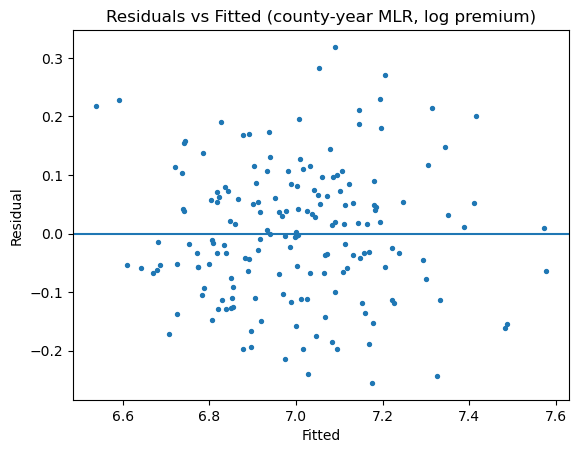

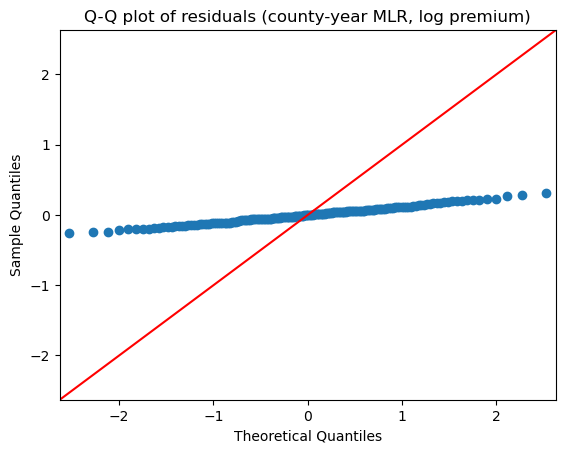


Breusch–Pagan test (heteroskedasticity):
{'LM stat': 28.60550213289334, 'LM p-value': 0.026735979215726968, 'F stat': 1.9305509754266859, 'F p-value': 0.021223920695072812}

Durbin–Watson (~2 good; <2 indicates positive autocorrelation): 0.9280272919131004

Top 15 influential county-years by Cook's distance:
     county_fips5       state    yr  prem_per_unit     prem_use  log_prem  \
37         6025.0  CALIFORNIA  2019     914.960832   914.960832  6.818881   
36         6025.0  CALIFORNIA  2018     858.633550   858.633550  6.755342   
113        6075.0  CALIFORNIA  2020    1859.700815  1859.700815  7.528171   
112        6075.0  CALIFORNIA  2019    1675.219153  1675.219153  7.423699   
40         6027.0  CALIFORNIA  2019    1011.636283  1011.636283  6.919324   
111        6075.0  CALIFORNIA  2018    1564.589424  1564.589424  7.355379   
128        6085.0  CALIFORNIA  2020    1189.707639  1189.707639  7.081463   
145        6097.0  CALIFORNIA  2019    1095.415674  1095.415674  6.998889

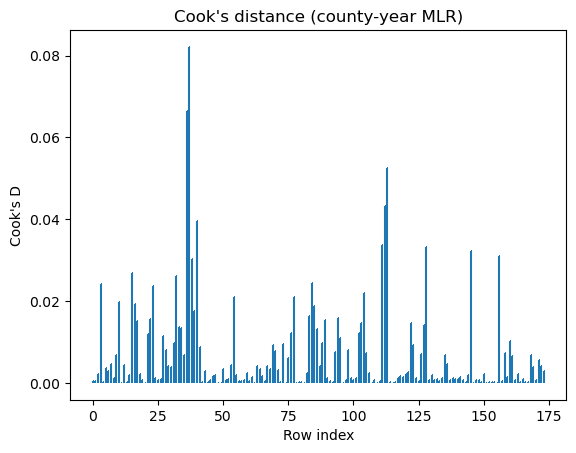

In [30]:
# -----------------------------
# 8) Assumption checks
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

# Residuals vs fitted
plt.figure()
plt.scatter(fitted, resid, s=8)
plt.axhline(0)
plt.title("Residuals vs Fitted (county-year MLR, log premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

# Q-Q plot
sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (county-year MLR, log premium)")
plt.show()

# Breusch–Pagan
bp = het_breuschpagan(resid, X)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch–Pagan test (heteroskedasticity):")
print(dict(zip(bp_labels, bp)))

# Durbin–Watson
dw = durbin_watson(resid)
print("\nDurbin–Watson (~2 good; <2 indicates positive autocorrelation):", float(dw))

# Cook's distance (influence)
infl = OLSInfluence(model)
cooks_d = infl.cooks_distance[0]

top_k = 15
top_idx = np.argsort(cooks_d)[-top_k:][::-1]

print(f"\nTop {top_k} influential county-years by Cook's distance:")
cols_to_show = ["county_fips5","state","yr","prem_per_unit","prem_use","log_prem"] + predictors
cols_to_show = [c for c in cols_to_show if c in df_m.columns]
print(df_m.iloc[top_idx][cols_to_show].assign(cooks_d=cooks_d[top_idx]).head(top_k))

plt.figure()
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.title("Cook's distance (county-year MLR)")
plt.xlabel("Row index")
plt.ylabel("Cook's D")
plt.show()

In [32]:
# Rebuild X pieces (same as your model)
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X_full = pd.concat([X_num, X_state], axis=1)

corr_full = X_full.corr(method="pearson")

print("\nCorrelation (full X, incl. state dummies) — showing top pairs only:")

corr_pairs_full = (
    corr_full.where(np.triu(np.ones(corr_full.shape), k=1).astype(bool))
    .stack()
    .rename("corr")
    .reset_index()
    .rename(columns={"level_0": "var1", "level_1": "var2"})
)
corr_pairs_full["abs_corr"] = corr_pairs_full["corr"].abs()
corr_pairs_full = corr_pairs_full.sort_values("abs_corr", ascending=False)

print(corr_pairs_full.head(50).round(3))



Correlation (full X, incl. state dummies) — showing top pairs only:
                          var1                       var2   corr  abs_corr
30            total_population        total_home_purchase  0.985     0.985
54         total_home_purchase         total_amt_purchase  0.982     0.982
33            total_population                   real_gdp  0.979     0.979
31            total_population         total_amt_purchase  0.977     0.977
66          total_amt_purchase                   real_gdp  0.975     0.975
56         total_home_purchase                   real_gdp  0.953     0.953
6                          hpi                   real_gdp  0.784     0.784
4                          hpi         total_amt_purchase  0.759     0.759
1                          hpi           total_population  0.694     0.694
43                   prop_rate         total_amt_purchase  0.691     0.691
42                   prop_rate        total_home_purchase  0.689     0.689
45                   prop_rate 

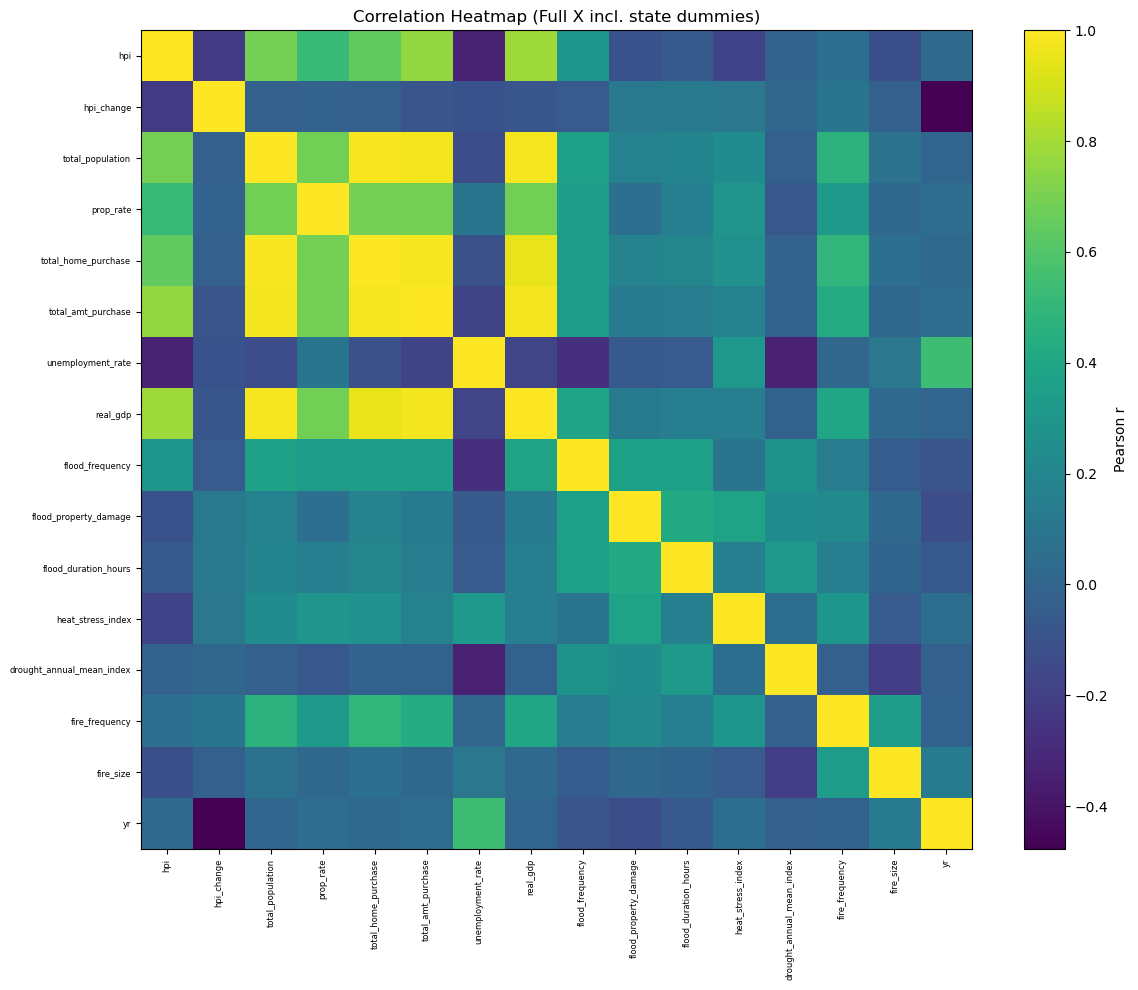

In [34]:
import matplotlib.pyplot as plt

# If X_full is very wide (many states), this will be unreadable.
# Consider plotting climate-only instead (see note below).
plt.figure(figsize=(12, 10))
plt.imshow(corr_full.values, aspect="auto")
plt.xticks(range(len(corr_full.columns)), corr_full.columns, rotation=90, fontsize=6)
plt.yticks(range(len(corr_full.index)), corr_full.index, fontsize=6)
plt.colorbar(label="Pearson r")
plt.title("Correlation Heatmap (Full X incl. state dummies)")
plt.tight_layout()
plt.show()


In [22]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -----------------------------
# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")

# -----------------------------
# 3) Coerce types
# -----------------------------
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["Earned Prem"] = pd.to_numeric(df.get("Earned Prem"), errors="coerce")
df["Earned Exp"]  = pd.to_numeric(df.get("Earned Exp"),  errors="coerce")
df["state"] = df["state"].astype(str)

climate_candidates = [
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size"
]
for c in climate_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 4) Aggregate ZIP -> county-year
# -----------------------------
id_cols = ["county_fips5", "state", "yr"]  # keep yr for grouping, but NOT as a predictor
base = df.dropna(subset=id_cols + ["Earned Prem","Earned Exp"]).copy()
base = base[base["Earned Exp"] > 0].copy()

cov_cols = [c for c in climate_candidates if c in base.columns]
agg_dict = {"Earned Prem": "sum", "Earned Exp": "sum"}
for c in cov_cols:
    agg_dict[c] = "first"  # assumes identical across ZIPs within county-year

cy = base.groupby(id_cols, as_index=False).agg(agg_dict)
cy["prem_per_unit"] = cy["Earned Prem"] / cy["Earned Exp"]

# -----------------------------
# 5) LOG target
# -----------------------------
cy = cy.dropna(subset=["prem_per_unit"]).copy()
cy = cy[cy["prem_per_unit"] > 0].copy()
cy["log_prem"] = np.log(cy["prem_per_unit"])

# -----------------------------
# 6) Climate predictors ONLY (yr dropped)
# -----------------------------
predictors = [c for c in climate_candidates if c in cy.columns]

df_m = cy.dropna(subset=["log_prem"] + predictors + ["county_fips5","state"]).copy()
print("MLR sample size:", df_m.shape)
print("Predictors:", predictors)

# Optional transforms for skewed climate severity vars
for c in ["flood_property_damage","fire_size"]:
    if c in df_m.columns:
        df_m[c] = np.log1p(df_m[c])

# Build X with state FE (keep this if you want to control for state pricing level differences)
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X = pd.concat([X_num, X_state], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem"]

# -----------------------------
# VIF
# -----------------------------
def compute_vif(X):
    Xv = X.copy()
    if "const" in Xv.columns:
        Xv = Xv.drop(columns=["const"])
    Xv = Xv.replace([np.inf, -np.inf], np.nan).dropna(axis=0)

    return (pd.DataFrame({
        "feature": Xv.columns,
        "VIF": [variance_inflation_factor(Xv.values, i) for i in range(Xv.shape[1])]
    }).sort_values("VIF", ascending=False))

vif_df = compute_vif(X)
print("\nTop VIFs:")
print(vif_df.head(25))

# -----------------------------
# 7) Fit OLS with clustered SE by county
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["county_fips5"]}
)

print("\n========== Climate-only County-year MLR (NO yr) on log(prem_per_unit) ==========")
print(model.summary())


MLR sample size: (174, 14)
Predictors: ['flood_frequency', 'flood_property_damage', 'flood_duration_hours', 'heat_stress_index', 'drought_annual_mean_index', 'fire_frequency', 'fire_size']

Top VIFs:
                     feature       VIF
3          heat_stress_index  5.254066
6                  fire_size  5.227540
5             fire_frequency  1.869772
1      flood_property_damage  1.786084
4  drought_annual_mean_index  1.699815
0            flood_frequency  1.633918
2       flood_duration_hours  1.599922

========== Climate-only County-year MLR (NO yr) on log(prem_per_unit) ==========
                            OLS Regression Results                            
Dep. Variable:               log_prem   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.276
Method:                 Least Squares   F-statistic:                     7.568
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           1.96e-06
Time:      

In [ ]:
# -----------------------------
# 8) Assumption checks
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

# Residuals vs fitted
plt.figure()
plt.scatter(fitted, resid, s=8)
plt.axhline(0)
plt.title("Residuals vs Fitted (county-year MLR, log premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

# Q-Q plot
sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (county-year MLR, log premium)")
plt.show()

# Breusch–Pagan
bp = het_breuschpagan(resid, X)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch–Pagan test (heteroskedasticity):")
print(dict(zip(bp_labels, bp)))

# Durbin–Watson
dw = durbin_watson(resid)
print("\nDurbin–Watson (~2 good; <2 indicates positive autocorrelation):", float(dw))

# Cook's distance (influence)
infl = OLSInfluence(model)
cooks_d = infl.cooks_distance[0]

top_k = 15
top_idx = np.argsort(cooks_d)[-top_k:][::-1]

print(f"\nTop {top_k} influential county-years by Cook's distance:")
cols_to_show = ["county_fips5","state","yr","prem_per_unit","prem_use","log_prem"] + predictors
cols_to_show = [c for c in cols_to_show if c in df_m.columns]
print(df_m.iloc[top_idx][cols_to_show].assign(cooks_d=cooks_d[top_idx]).head(top_k))

plt.figure()
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.title("Cook's distance (county-year MLR)")
plt.xlabel("Row index")
plt.ylabel("Cook's D")
plt.show()

Winsor 1%/99%: 571.7662565339767 5190.254651625734
Target used: log_prem = log(prem_use)
count    5549.000000
mean        7.040384
std         0.403639
min         6.348730
25%         6.754459
50%         6.980785
75%         7.237032
max         8.554538
Name: log_prem, dtype: float64

MLR sample size: (5549, 27)
Predictors: ['Earned Exp', 'hpi', 'hpi_change', 'total_population', 'prop_rate', 'total_home_purchase', 'total_amt_purchase', 'unemployment_rate', 'real_gdp', 'flood_frequency', 'flood_property_damage', 'flood_duration_hours', 'heat_stress_index', 'drought_annual_mean_index', 'fire_frequency', 'fire_size', 'yr']

========== ZIP-year MLR on log(prem_per_unit) ==========
                            OLS Regression Results                            
Dep. Variable:               log_prem   R-squared:                       0.208
Model:                            OLS   Adj. R-squared:                  0.206
Method:                 Least Squares   F-statistic:                     1

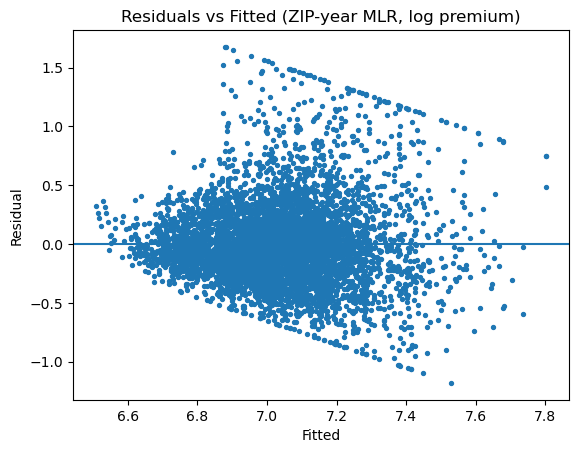

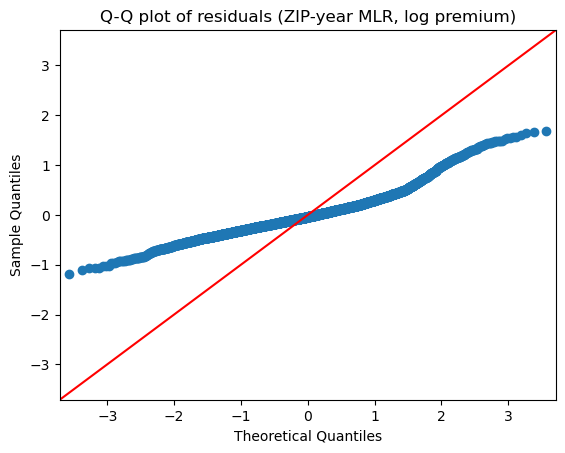


Breusch–Pagan test (heteroskedasticity):
{'LM stat': 857.8047318846345, 'LM p-value': 2.153806349251273e-171, 'F stat': 59.49214997948286, 'F p-value': 8.037353275288027e-187}

Durbin–Watson (~2 good; <2 indicates positive autocorrelation): 0.6497467795441687

Top 15 influential ZIP-years by Cook's distance:
      ZIP Code  county_fips5       state    yr  prem_per_unit     prem_use  \
4249     95402        6097.0  CALIFORNIA  2019   13021.000000  5190.254652   
3174     94158        6075.0  CALIFORNIA  2020     472.800000   571.766257   
3144     94123        6075.0  CALIFORNIA  2020    5171.018232  5171.018232   
3123     94115        6075.0  CALIFORNIA  2020    6452.941414  5190.254652   
1282     92235        6065.0  CALIFORNIA  2020    5979.000000  5190.254652   
2762     93642        6019.0  CALIFORNIA  2019    3077.000000  3077.000000   
3108     94109        6075.0  CALIFORNIA  2020    5043.259197  5043.259197   
3121     94115        6075.0  CALIFORNIA  2018    5340.996545  51

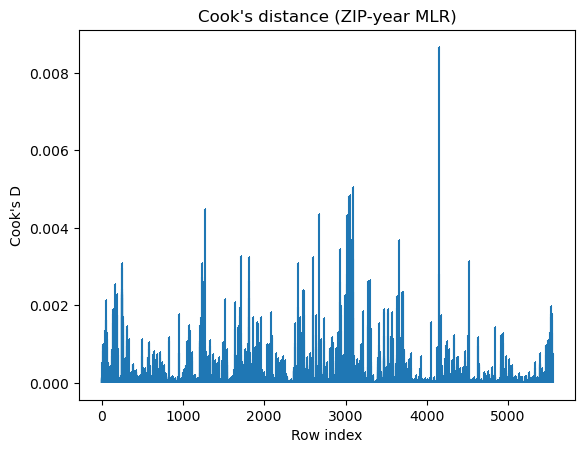

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import OLSInfluence

from pathlib import Path

# -----------------------------
# 2) Drop hurricane features
# -----------------------------
hurr_cols = ["deaths_hurricane", "injuries_hurricane", "damage_hurricane"]
df = df.drop(columns=[c for c in hurr_cols if c in df.columns], errors="ignore")

# -----------------------------
# 3) Coerce types
# -----------------------------
df["yr"] = pd.to_numeric(df["yr"], errors="coerce")
df["county_fips5"] = pd.to_numeric(df["county_fips5"], errors="coerce")
df["ZIP Code"] = pd.to_numeric(df["ZIP Code"], errors="coerce")  # keep numeric zip id
df["Earned Exp"] = pd.to_numeric(df.get("Earned Exp"), errors="coerce")
df["Earned Prem"] = pd.to_numeric(df.get("Earned Prem"), errors="coerce")
df["state"] = df["state"].astype(str)

numeric_candidates = [
    "prem_per_unit",
    "hpi_change","hpi",
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",
    "real_gdp","unemployment_rate","prop_rate",
    "total_home_purchase","total_amt_purchase","total_population"
]
for c in numeric_candidates:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# -----------------------------
# 4) Ensure prem_per_unit exists (no leakage in X later)
# -----------------------------
if "prem_per_unit" not in df.columns or df["prem_per_unit"].isna().all():
    if ("Earned Prem" in df.columns) and ("Earned Exp" in df.columns):
        df["prem_per_unit"] = df["Earned Prem"] / df["Earned Exp"]
    else:
        raise ValueError("prem_per_unit missing and cannot be constructed (need Earned Prem and Earned Exp).")

# basic target cleaning
df = df.dropna(subset=["prem_per_unit", "yr", "ZIP Code", "state"]).copy()
df = df[df["prem_per_unit"] > 0].copy()

# -----------------------------
# 5) LOG target (optionally winsorize first)
# -----------------------------
USE_WINSOR = True  # set False if you want pure log without clipping

if USE_WINSOR:
    lo, hi = df["prem_per_unit"].quantile([0.01, 0.99])
    df["prem_use"] = df["prem_per_unit"].clip(lo, hi)
    print("Winsor 1%/99%:", float(lo), float(hi))
else:
    df["prem_use"] = df["prem_per_unit"]

df["log_prem"] = np.log(df["prem_use"])
print("Target used: log_prem = log(prem_use)")
print(df["log_prem"].describe())

# -----------------------------
# 6) MLR predictors (ZIP-year level)
#    Exclude Earned Prem (leakage); Earned Exp is OK as exposure/size control.
# -----------------------------
predictors = [
    # exposure / portfolio size (OK)
    "Earned Exp",

    # housing/market
    "hpi", "hpi_change",
    "total_population", "prop_rate",
    "total_home_purchase", "total_amt_purchase",

    # macro
    "unemployment_rate", "real_gdp",

    # climate
    "flood_frequency","flood_property_damage","flood_duration_hours",
    "heat_stress_index","drought_annual_mean_index",
    "fire_frequency","fire_size",

    # time trend
    "yr"
]
predictors = [c for c in predictors if c in df.columns]

df_m = df.dropna(subset=["log_prem"] + predictors).copy()
print("\nMLR sample size:", df_m.shape)
print("Predictors:", predictors)

# Optional transforms for skewed Xs (helps linearity)
for c in ["real_gdp","total_population","total_amt_purchase","total_home_purchase",
          "flood_property_damage","fire_size","Earned Exp"]:
    if c in df_m.columns:
        df_m[c] = np.log1p(df_m[c])

# Build X with state fixed effects
X_num = df_m[predictors].copy()
X_state = pd.get_dummies(df_m["state"], prefix="state", drop_first=True)
X = pd.concat([X_num, X_state], axis=1)
X = sm.add_constant(X)

y = df_m["log_prem"]

# -----------------------------
# 7) Fit OLS with clustered SE by ZIP (panel-safe inference)
# -----------------------------
model = sm.OLS(y, X).fit(
    cov_type="cluster",
    cov_kwds={"groups": df_m["ZIP Code"]}
)

print("\n========== ZIP-year MLR on log(prem_per_unit) ==========")
print(model.summary())

# -----------------------------
# 8) Assumption checks
# -----------------------------
resid = model.resid
fitted = model.fittedvalues

# Residuals vs fitted
plt.figure()
plt.scatter(fitted, resid, s=8)
plt.axhline(0)
plt.title("Residuals vs Fitted (ZIP-year MLR, log premium)")
plt.xlabel("Fitted")
plt.ylabel("Residual")
plt.show()

# Q-Q plot
sm.qqplot(resid, line="45")
plt.title("Q-Q plot of residuals (ZIP-year MLR, log premium)")
plt.show()

# Breusch–Pagan (on OLS residuals; inference uses clustered SE anyway)
bp = het_breuschpagan(resid, X)
bp_labels = ["LM stat", "LM p-value", "F stat", "F p-value"]
print("\nBreusch–Pagan test (heteroskedasticity):")
print(dict(zip(bp_labels, bp)))

# Durbin–Watson (serial correlation indicator; panel data usually <2)
dw = durbin_watson(resid)
print("\nDurbin–Watson (~2 good; <2 indicates positive autocorrelation):", float(dw))

# Cook's distance (influence)
infl = OLSInfluence(model)
cooks_d = infl.cooks_distance[0]

top_k = 15
top_idx = np.argsort(cooks_d)[-top_k:][::-1]

print(f"\nTop {top_k} influential ZIP-years by Cook's distance:")
cols_to_show = ["ZIP Code","county_fips5","state","yr","prem_per_unit","prem_use","log_prem"] + predictors
cols_to_show = [c for c in cols_to_show if c in df_m.columns]
print(df_m.iloc[top_idx][cols_to_show].assign(cooks_d=cooks_d[top_idx]).head(top_k))

plt.figure()
plt.stem(cooks_d, markerfmt=",", basefmt=" ")
plt.title("Cook's distance (ZIP-year MLR)")
plt.xlabel("Row index")
plt.ylabel("Cook's D")
plt.show()

